In [163]:
import retrieval
from collections import Counter
from typing import List, Dict
import re
import matplotlib.pyplot as plt
import numpy as np

In [164]:
retrieval.initialize_search()
transcripts = retrieval._SEARCH_DATA["transcripts"]
good_words = retrieval._SEARCH_DATA["vocab"]

##### Corpus Stats

In [165]:
def build_word_document_count(transcripts: List[Dict]) -> Dict[str, int]:

    doc_count = Counter()

    for doc in transcripts:

        unique_tokens = set(doc["tokens"])

        doc_count.update(unique_tokens)

    return dict(doc_count)


In [166]:
def build_word_corpus_count(transcripts: List[Dict]) -> Dict[str, int]:

    corpus_count = Counter()

    for doc in transcripts:

        corpus_count.update(doc["tokens"])

    return dict(corpus_count)


In [167]:
def print_top_10_common_words(transcripts: List[Dict]):

    corpus_count = build_word_corpus_count(transcripts)

    doc_count = build_word_document_count(transcripts)

    n_docs = len(transcripts)

    ranked = sorted(
        corpus_count.items(),
        key=lambda x: x[1],
        reverse=True
    )[:10]

    print("word | corpus_count | transcript_fraction")
    print("------------------------------------------")

    for word, count in ranked:

        frac = doc_count[word] / n_docs

        print(f"{word:15s} {count:10d} {frac:.4f}")


In [168]:
print_top_10_common_words(transcripts)

word | corpus_count | transcript_fraction
------------------------------------------
fuck                 15405 0.7773
uh                    4161 0.7666
white                 3346 0.7901
girl                  3288 0.7752
women                 2913 0.7859
babi                  2821 0.7794
black                 2757 0.7323
gotta                 2754 0.6852
dad                   2593 0.6938
wanna                 2583 0.6424


In [169]:
def search_word(word: str) -> None:
    for doc in transcripts:
        match = re.search(rf"\.[^.]*{word}[^.]*\.[\"”]?", doc['content'], flags=re.IGNORECASE)
        if match:
            print(f"[{transcripts.index(doc)}] {doc['title']}")
            print(match.group()[2:])

In [170]:
search_word('9/11')

[3] Election Results 2020: Last Week Tonight with John Oliver – Transcript
There was a mood here that can only be described as a “reverse 9/11.”
[21] Bo Burnham: What (2013) – Transcript
The holocaust and 9/11, that shit’s funny 24/7.
[26] D.L. Hughley: Unapologetic (2007) – Transcript
And his sole qualification is that he was mayor of New York when 9/11 happen’.
[43] Jim Norton: Contextually Inadequate (2015) – Transcript
And I think she was the most brutal… and I say that with affection… the most brutal comic I ever saw perform! She made fun of AIDS, she made fun of 9/11, I mean, recently she called Michelle Obama a “trannie!” I’d be scared to text that to somebody! And when they asked her about it, expecting an apology, like, “Why did you say that?” She’s, like, “Oh! Look at her!” Joan Rivers was wonderful! I would have eaten her pussy 10 minutes after she died! God bless Joan Rivers! Because she never gave them what they wanted! She never said she was sorry.
[46] Sarah Silverman: J

##### Determine thresholds for good words

In [171]:
doc_freq = Counter()

for doc in transcripts:
    unique_tokens = set(doc["tokens"])
    doc_freq.update(unique_tokens)

n_docs = len(transcripts)
df_values = list(doc_freq.values())

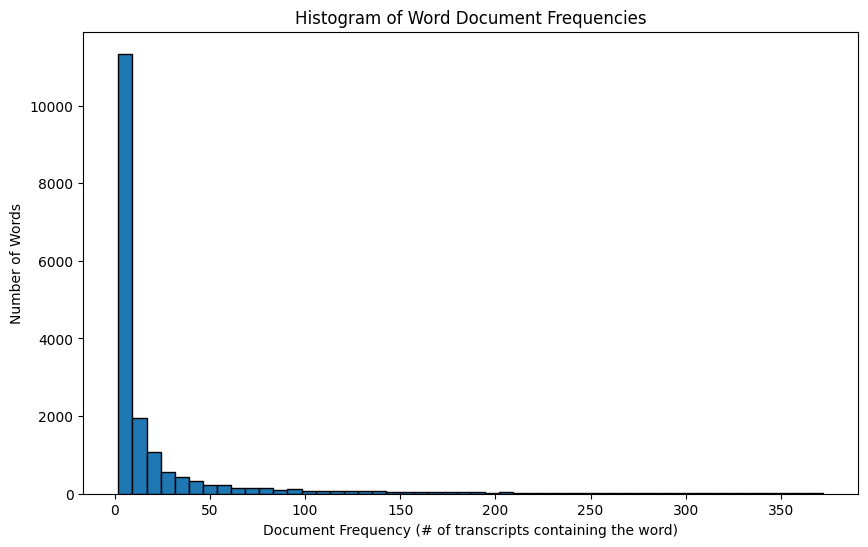

In [172]:
plt.figure(figsize=(10, 6))
plt.hist(df_values, bins=50, edgecolor="black")
plt.xlabel("Document Frequency (# of transcripts containing the word)")
plt.ylabel("Number of Words")
plt.title("Histogram of Word Document Frequencies")
plt.show()


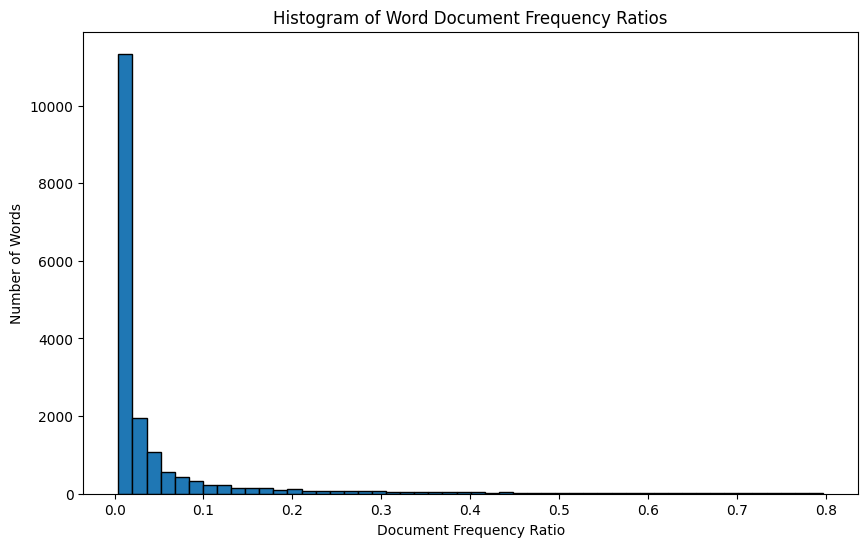

In [173]:
df_ratios = [df / n_docs for df in doc_freq.values()]

plt.figure(figsize=(10, 6))
plt.hist(df_ratios, bins=50, edgecolor="black")
plt.xlabel("Document Frequency Ratio")
plt.ylabel("Number of Words")
plt.title("Histogram of Word Document Frequency Ratios")
plt.show()


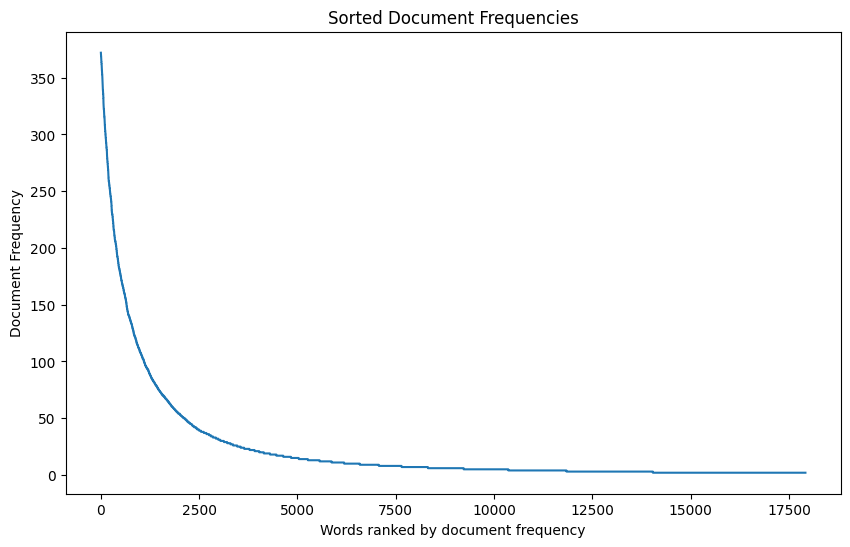

In [174]:
sorted_dfs = sorted(doc_freq.values(), reverse=True)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(sorted_dfs) + 1), sorted_dfs)
plt.xlabel("Words ranked by document frequency")
plt.ylabel("Document Frequency")
plt.title("Sorted Document Frequencies")
plt.show()


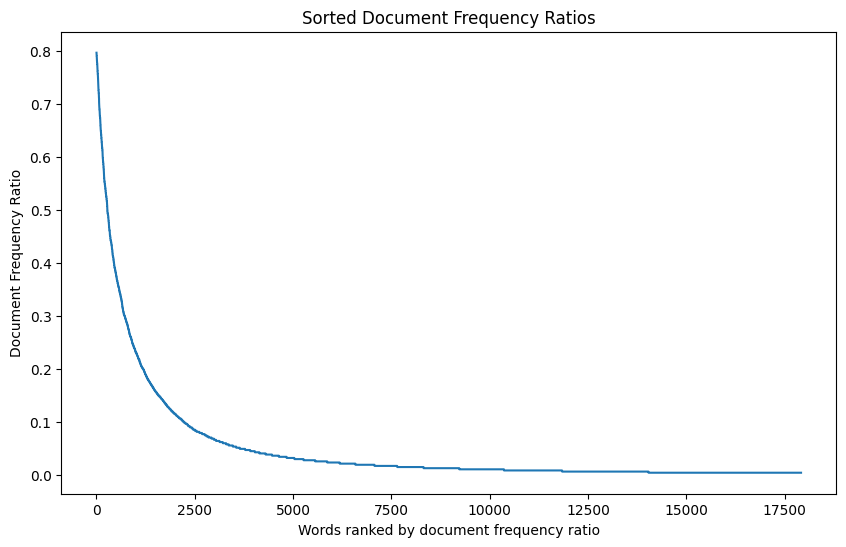

In [175]:
sorted_ratios = sorted((df / n_docs for df in doc_freq.values()), reverse=True)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(sorted_ratios) + 1), sorted_ratios)
plt.xlabel("Words ranked by document frequency ratio")
plt.ylabel("Document Frequency Ratio")
plt.title("Sorted Document Frequency Ratios")
plt.show()


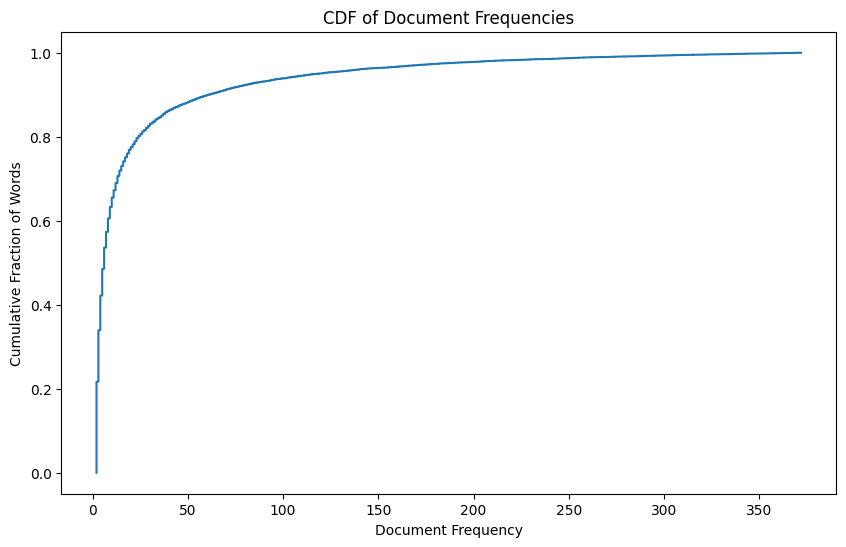

In [176]:
df_values = np.array(sorted(doc_freq.values()))

y = np.arange(1, len(df_values) + 1) / len(df_values)

plt.figure(figsize=(10, 6))
plt.plot(df_values, y)
plt.xlabel("Document Frequency")
plt.ylabel("Cumulative Fraction of Words")
plt.title("CDF of Document Frequencies")
plt.show()


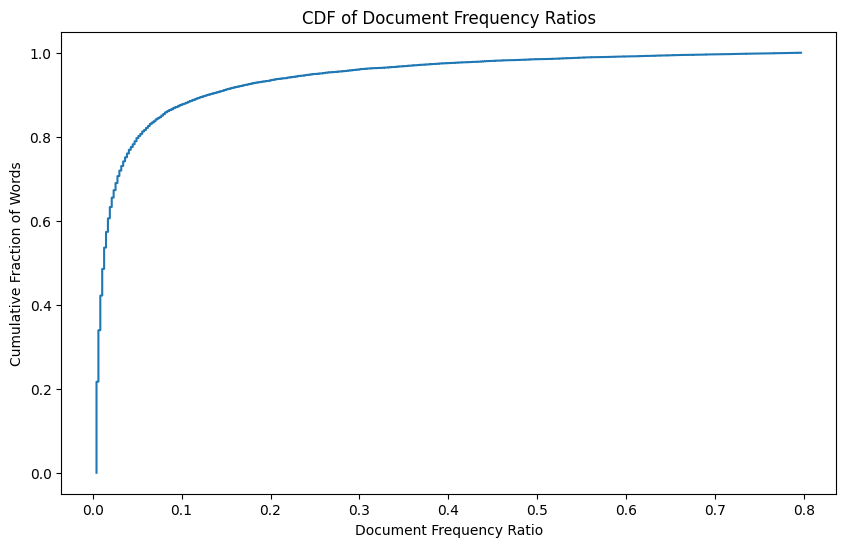

In [177]:
df_ratios = np.array(sorted(df / n_docs for df in doc_freq.values()))
y = np.arange(1, len(df_ratios) + 1) / len(df_ratios)

plt.figure(figsize=(10, 6))
plt.plot(df_ratios, y)
plt.xlabel("Document Frequency Ratio")
plt.ylabel("Cumulative Fraction of Words")
plt.title("CDF of Document Frequency Ratios")
plt.show()


In [178]:
def print_threshold_sweep(min_df_values=None, max_df_ratio_values=None):

    if min_df_values is None:
        min_df_values = [1, 2, 3, 5, 10]

    if max_df_ratio_values is None:
        max_df_ratio_values = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

    print("Rare-word threshold sweep")
    print("min_df | words_kept")
    print("-------------------")
    for min_df in min_df_values:
        kept = sum(1 for df in doc_freq.values() if df >= min_df)
        print(f"{min_df:6d} | {kept:10d}")

    print("\nCommon-word threshold sweep")
    print("max_df_ratio | words_kept")
    print("-------------------------")
    for max_ratio in max_df_ratio_values:
        kept = sum(1 for df in doc_freq.values() if (df / n_docs) <= max_ratio)
        print(f"{max_ratio:12.2f} | {kept:10d}")


In [179]:
print_threshold_sweep()

Rare-word threshold sweep
min_df | words_kept
-------------------
     1 |      17917
     2 |      17917
     3 |      14036
     5 |      10361
    10 |       6583

Common-word threshold sweep
max_df_ratio | words_kept
-------------------------
        0.50 |      17641
        0.60 |      17759
        0.70 |      17850
        0.80 |      17917
        0.90 |      17917
        0.95 |      17917


In [180]:
def plot_threshold_heatmap(
    transcripts,
    min_df_values=None,
    max_df_ratio_values=None
):

    if min_df_values is None:
        min_df_values = [1, 2, 3, 5, 10]

    if max_df_ratio_values is None:
        max_df_ratio_values = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

    heatmap = np.zeros((len(min_df_values), len(max_df_ratio_values)))

    for i, min_df in enumerate(min_df_values):
        for j, max_ratio in enumerate(max_df_ratio_values):
            kept = sum(
                1 for df in doc_freq.values()
                if df >= min_df and (df / n_docs) <= max_ratio
            )
            heatmap[i, j] = kept

    plt.figure(figsize=(10, 6))
    plt.imshow(heatmap, aspect="auto")
    plt.colorbar(label="Number of Words Kept")
    plt.xticks(range(len(max_df_ratio_values)), max_df_ratio_values)
    plt.yticks(range(len(min_df_values)), min_df_values)
    plt.xlabel("max_df_ratio")
    plt.ylabel("min_df")
    plt.title("Vocabulary Size Under Different Thresholds")
    plt.show()


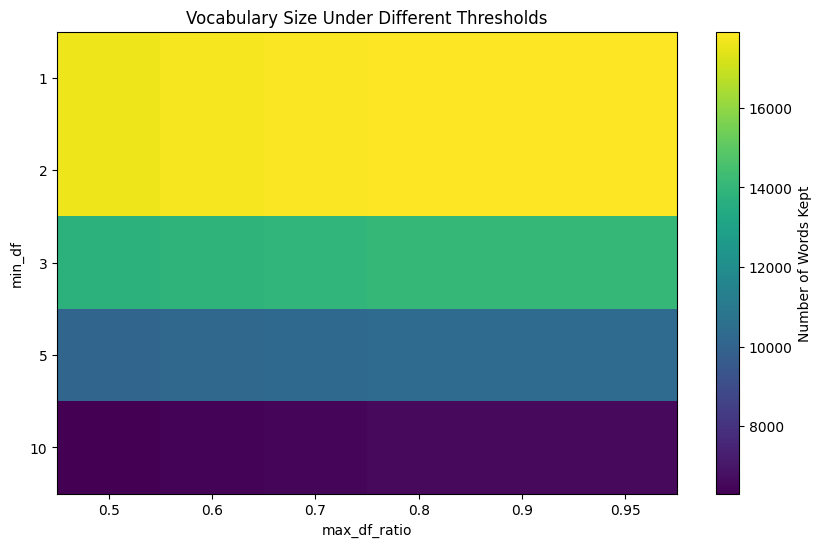

In [181]:
plot_threshold_heatmap(transcripts)

In [182]:
def plot_top_common_words_by_doc_fraction(top_k=20):
    corpus_freq = build_word_corpus_count(transcripts)

    ranked = sorted(corpus_freq.items(), key=lambda x: x[1], reverse=True)[:top_k]

    words = [w for w, _ in ranked]
    fractions = [doc_freq[w] / n_docs for w in words]

    plt.figure(figsize=(12, 6))
    plt.bar(words, fractions)
    plt.xticks(rotation=60, ha="right")
    plt.xlabel("Word")
    plt.ylabel("Fraction of Transcripts Containing Word")
    plt.title(f"Top {top_k} Common Words by Transcript Coverage")
    plt.show()


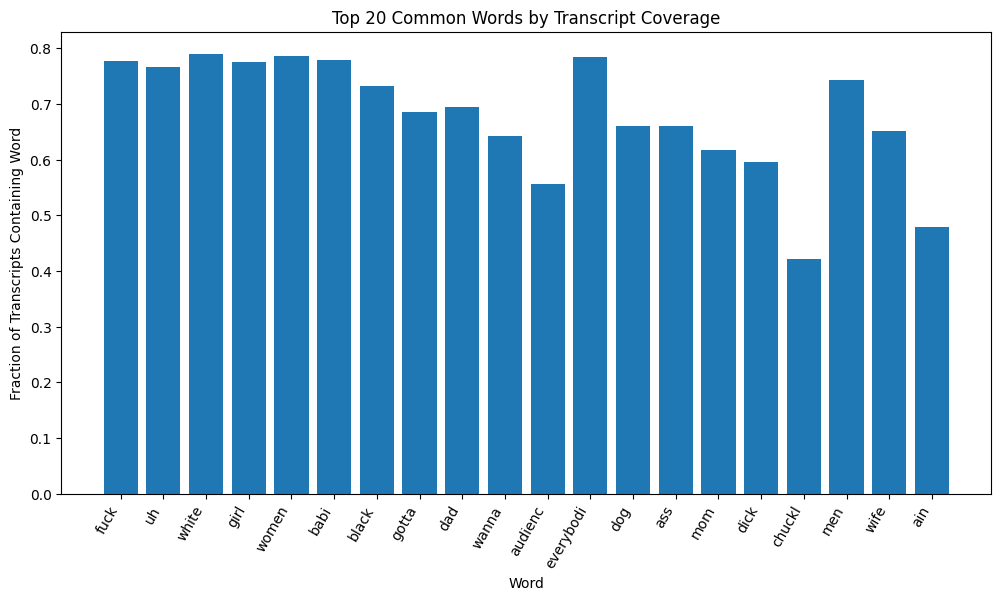

In [183]:
plot_top_common_words_by_doc_fraction(top_k=20)

##### Run Search

In [184]:
def print_sentence_retrieval_results(results):
    for rank, result in enumerate(results, start=1):
        print("=" * 100)
        print(f"Rank {rank}")
        print(f"Title: {result['title']}")
        print(f"Comedian: {result['comedian']}")
        print(f"Special: {result['special_title']}")
        print(f"Year: {result['release_date']}")
        print(f"Transcript score: {result['transcript_score']:.4f}")
        print(f"Sentence score: {result['sentence_score']:.4f}")
        print(f"Best sentence index: {result['best_sentence_index']}")
        print("-" * 100)

        for sentence in result["context_sentences"]:
            print(sentence)

        print()


In [185]:
def print_search(query: str,
                 top_k: int = 5,
                 context_window: int = 1,
                 match_window: int = 1) -> None:
    print_sentence_retrieval_results(retrieval.search(query, top_k=top_k, context_window=context_window, match_window=match_window))

In [186]:
print_search("9/11 jokes")

Rank 1
Title: RICKY GERVAIS: LIVE IV – SCIENCE (2010) – Full Transcript
Comedian: RICKY GERVAIS
Special: LIVE IV – SCIENCE
Year: 2010
Transcript score: 0.0920
Sentence score: 1.0000
Best sentence index: 1526
----------------------------------------------------------------------------------------------------
"Yeah, but what…" "Don't give it 'It won't happen to us.'
They said that on 9/11 ."
"Yeah, but what about all the checks?"

Rank 2
Title: Sammy Obeid: Charlie Kirk – America’s Turning Point? | Transcript
Comedian: Sammy Obeid
Special: Charlie Kirk – America’s Turning Point?
Year: 
Transcript score: 0.0702
Sentence score: 1.0000
Best sentence index: 218
----------------------------------------------------------------------------------------------------
For you guys, this happened on 9/10.
But for me, it was 9/11.
And I know you don't relate, because for you it was 9/10.

Rank 3
Title: Jim Jefferies: Two Limb Policy (2025) | Transcript
Comedian: Jim Jefferies
Special: Two Limb Policy


In [187]:
print_search("dating in your 30's")

Rank 1
Title: Joe DeVito: Middle-Aged Dating | Transcript
Comedian: Joe DeVito
Special: Middle-Aged Dating
Year: 
Transcript score: 0.1503
Sentence score: 0.5767
Best sentence index: 288
----------------------------------------------------------------------------------------------------
It's terrifying.
Oh man, and like I said, I'm trying to date—try dating younger women.
That's a mistake.

Rank 2
Title: Iliza Shlesinger: Freezing Hot (2015) – Full Transcript
Comedian: Iliza Shlesinger
Special: Freezing Hot
Year: 2015
Transcript score: 0.1386
Sentence score: 0.7936
Best sentence index: 665
----------------------------------------------------------------------------------------------------
I should have been mature about it.
And had I been dating more in my 30s, I think I would have been okay with that situation.
My friends in their mid-30s, they'd be okay with that drink.

Rank 3
Title: Bo Burnham: Inside (2021) | Transcript
Comedian: Bo Burnham
Special: Inside
Year: 2021
Transcript sc

In [188]:
print_search("old age jokes")

Rank 1
Title: Joe DeVito: Middle-Aged Dating | Transcript
Comedian: Joe DeVito
Special: Middle-Aged Dating
Year: 
Transcript score: 0.0896
Sentence score: 0.4511
Best sentence index: 19
----------------------------------------------------------------------------------------------------
But it is a strange age to be single at 50.
I didn't think that was going to happen to me, and it's because dating is not designed for people my age.
You don't hear a lot about single guys my age because we're gross, we're creepy.

Rank 2
Title: GREG DAVIES: YOU MAGNIFICENT BEAST (2018) – Full Transcript
Comedian: GREG DAVIES
Special: YOU MAGNIFICENT BEAST
Year: 2018
Transcript score: 0.0800
Sentence score: 0.7613
Best sentence index: 147
----------------------------------------------------------------------------------------------------
We think we can make you a giant bear."
And I remember thinking, "Uh…" I was only eight years of age, but I thought, "Oh… that sounds shit, doesn't it?
That sounds shit.

In [189]:
print_search("marriage wife kids family")

Rank 1
Title: Seth Meyers: Lobby Baby (2019) – Full Transcript
Comedian: Seth Meyers
Special: Lobby Baby
Year: 2019
Transcript score: 0.2173
Sentence score: 0.5458
Best sentence index: 300
----------------------------------------------------------------------------------------------------
And the first question was, "Mother's name?"
And I put my wife's name.
And then, it said, "Mother's phone number."

Rank 2
Title: Seth Meyers: Dad Man Walking (2024) | Transcript
Comedian: Seth Meyers
Special: Dad Man Walking
Year: 2024
Transcript score: 0.1873
Sentence score: 0.8379
Best sentence index: 598
----------------------------------------------------------------------------------------------------
This is all– what I've been doing is all a very good example of how it is hard to be married to a comedian.
I just get to come up here and tell you guys what I'm thinking about my marriage.
And so, yes, it is hard to be married to a comedian.

Rank 3
Title: Sebastian Maniscalco Stand-Up – The Tonig

##### Other Testing

In [190]:
'30' in good_words

True